<a href="https://colab.research.google.com/github/estefania-apaza/inferencia-causal-proyecto-lengua-enaho2024/blob/main/Actividad%202/TC2_Salinas_Apaza_Perez_Marcos_20231724_20230487_20212237_20221214.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea Calificada 2


**Efecto de tener una lengua materna indígena en la confianza hacia la Policía Nacional**

Base de datos: Encuesta Nacional de Hogares 2024

X: Lengua materna indígena

Y: Nivel de confianza en la Policía

Enlace del repositorio de GitHub: https://github.com/estefania-apaza/inferencia-causal-proyecto-lengua-enaho2024/tree/main



*   20231724 - Adrian Salinas Alcántara
*   20230487 - Estefanía Apaza Díaz
*   20212237 - Maria Jesus Perez Zarate
*   20221214 - Fabiana Marcos




# Regresión Lineal Múltiple

In [ ]:
import os
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
# Cargamos la base modificada en la TC1

import pandas as pd

# URL "raw" de tu archivo CSV en GitHub
url = "https://raw.githubusercontent.com/estefania-apaza/inferencia-causal-proyecto-lengua-enaho2024/refs/heads/main/Actividad%202/enaho_limpia_t1.csv"

# Cargar el CSV
data = pd.read_csv(url, encoding="latin-1")

data.head(2)
data.columns

Index(['conglome', 'vivienda', 'hogar', 'codperso', 'p208a', 'p207', 'p300a',
       'p301a', 'p1$06', 'estrsocial', 'dominio', 'dom_2', 'dom_3', 'dom_4',
       'dom_5', 'dom_6', 'dom_7', 'dom_8', 'estrsoc_2.0', 'estrsoc_3.0',
       'estrsoc_4.0', 'estrsoc_5.0', 'estrsoc_6.0', 'educ_2.0', 'educ_3.0',
       'educ_4.0', 'educ_5.0', 'educ_6.0', 'educ_7.0', 'educ_8.0', 'educ_10.0',
       'educ_11.0', 'educ_12.0', 'lengua_indigena', 'conf_policia'],
      dtype='object')

**La base cargada fue preparada para la Tarea Calificada 1**. Se presenta una descripción:

Variable independiente: lengua_indigena

```
0: No habla lengua indígena
1: Habla lengua indígena
```

Variable dependiente: conf_policia

```
# Ya se han eliminado los NN
1. Nada
2. Poco
3. Suficiente
4. Bastante
```

Variables de control:

*   p208a: edad (en números)
*   p207: sexo
```
1. Hombre
2. Mujer
```
*   dom_*
```
# Dummies basadas en los siguientes valores:
1.Costa Norte
2.Costa Centro
3.Costa Sur
4.Sierra Norte
5.Sierra Centro
6.Sierra Sur
7.Selva
8.Lima Metropolitana
```

*   estrsoc_*

```
# Dummies basadas en los siguientes valores:
1.A
2.B
3.C
4.D
5.E
6. Rural
```

*   educ_*

```
# Dummies basadas en la pregunta: ¿Cuál es el último año o grado de estudios y nivel que aprobó?
```

**Sobre esta base se trabajará a continuación.**

In [18]:
# Revisamos que todas las variables sean numéricas
# Solo colocamos dos dummies de cada uno como ejemplo

variables = ['p208a', 'p207','p301a','educ_4.0','educ_5.0','lengua_indigena','conf_policia','dom_5', 'dom_6','estrsoc_2.0', 'estrsoc_3.0']

data[variables].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5046 entries, 0 to 5045
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   p208a            5046 non-null   int64  
 1   p207             5046 non-null   int64  
 2   p301a            5046 non-null   float64
 3   educ_4.0         5046 non-null   int64  
 4   educ_5.0         5046 non-null   int64  
 5   lengua_indigena  5046 non-null   int64  
 6   conf_policia     5046 non-null   float64
 7   dom_5            5046 non-null   int64  
 8   dom_6            5046 non-null   int64  
 9   estrsoc_2.0      5046 non-null   int64  
 10  estrsoc_3.0      5046 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 433.8 KB


In [20]:
# Evaluamos la mediana de conf_policia para crear la variable dicotómica
mediana = data['conf_policia'].median()
print("Mediana de conf_policia:", mediana)

Mediana de conf_policia: 2.0


In [21]:
# Creamos la variable dicotómica usando la mediana
data['conf_policia_dic'] = (data['conf_policia'] > data['conf_policia'].median()).astype(int)

# Revisamos distribución
data['conf_policia_dic'].value_counts()

,count
conf_policia_dic,
0,4065
1,981


In [23]:
# Cambiamos nombres de variables para facilitar el tratamiento

data = data.rename(columns={
    'p208a': 'edad',
    'p207': 'sexo',})

# Filtramos la data por las columnas a usar

cols_usar = ['edad', 'sexo',
             'dom_2', 'dom_3', 'dom_4', 'dom_5', 'dom_6', 'dom_7', 'dom_8',
             'estrsoc_2.0', 'estrsoc_3.0', 'estrsoc_4.0', 'estrsoc_5.0', 'estrsoc_6.0',
             'educ_2.0', 'educ_3.0', 'educ_4.0', 'educ_5.0', 'educ_6.0', 'educ_7.0', 'educ_8.0', 'educ_10.0', 'educ_11.0', 'educ_12.0',
             'lengua_indigena', 'conf_policia_dic']

data = data[cols_usar].copy()

In [24]:
# Revisamos la data final para el análisis
data.head(3)

,edad,sexo,dom_2,dom_3,dom_4,dom_5,dom_6,dom_7,dom_8,estrsoc_2.0,...,educ_4.0,educ_5.0,educ_6.0,educ_7.0,educ_8.0,educ_10.0,educ_11.0,educ_12.0,lengua_indigena,conf_policia_dic
0,65,1,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,33,2,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,58,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


## DESDE AQUÍ EDITAR

#### Ejercicios Prácticos - ENAHO (Módulo 5: Empleo e Ingresos)

VARIABLE DEPENDIENTE (Y): Ingreso mensual

p523: En su ocupación principal, ¿A usted le pagan

    1 Diario
    2 Semanal
    3 Quincenal
    4 Mensual
    
p524a1: Ingreso total (en la frecuencia anterior)
     
VARIABLES EXPLICATIVAS (X):

* Horas de trabajo

    p513t: ¿Cuántas horas trabajó la semana pasada, en su ocupación principal en total?

* Sexo (p207)

* Nivel educativo (p301a)

* Área (estrato)

* Edad (p208a)

In [ ]:
#,'estrato'
variables =['p523','p524a1','p513t', 'p207','p301a','p208a']
data = modulo_5[variables].copy()
data.info()
# Dtype: object, indica que la columna contiene valores que no son puramente numéricos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86654 entries, 0 to 86653
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   p523    86654 non-null  object
 1   p524a1  86654 non-null  object
 2   p513t   86654 non-null  object
 3   p207    86654 non-null  int64 
 4   p301a   86654 non-null  object
 5   p208a   86654 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 4.0+ MB


In [ ]:
# Transformamos los datos a valores numéricos:
#data = data.apply(pd.to_numeric, errors="coerce")
#

# 2. Convertir a numérico SOLO las columnas de datos (Evitamos el error "nuclear")
# p523, p524a1, p513t suelen ser ingresos/horas; p207 sexo; p301a educ; p208a edad.
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data.dropna(inplace=True)
data

,p523,p524a1,p513t,p207,p301a,p208a
0,4.0,1800.0,28.0,1,8.0,43
5,4.0,1900.0,45.0,1,8.0,30
9,4.0,2100.0,0.0,2,10.0,50
13,4.0,650.0,93.0,2,6.0,17
15,4.0,50.0,40.0,2,4.0,59
...,...,...,...,...,...,...
86633,2.0,160.0,20.0,1,3.0,74
86634,2.0,160.0,20.0,2,3.0,65
86635,4.0,1460.0,48.0,1,4.0,41
86636,2.0,90.0,24.0,2,1.0,41


In [ ]:
print("Tipos de datos:", modulo_5['estrato'].dtype)
print("Valores únicos:", modulo_5['estrato'].unique())

Tipos de datos: int64
Valores únicos: [4 7 3 1 5 2 6 8]


In [ ]:
data['estrato'] = pd.to_numeric(modulo_5['estrato'], errors='coerce')
data

,p523,p524a1,p513t,p207,p301a,p208a,estrato
0,4.0,1800.0,28.0,1,8.0,43,4
5,4.0,1900.0,45.0,1,8.0,30,4
9,4.0,2100.0,0.0,2,10.0,50,4
13,4.0,650.0,93.0,2,6.0,17,4
15,4.0,50.0,40.0,2,4.0,59,7
...,...,...,...,...,...,...,...
86633,2.0,160.0,20.0,1,3.0,74,5
86634,2.0,160.0,20.0,2,3.0,65,5
86635,4.0,1460.0,48.0,1,4.0,41,5
86636,2.0,90.0,24.0,2,1.0,41,5


In [ ]:
# Creación de variables:

# INGRESO MENSUAL
# Diccionario con los multiplicadores de frecuencia
multiplicadores = {
    1: 30,  # Diario
    2: 4,   # Semanal
    3: 2,   # Quincenal
    4: 1    # Mensual
}
# Calcular el ingreso mensual usando el diccionario
data['ingreso_mensual'] = data['p524a1'] * data['p523'].map(multiplicadores)
# Creamos una nueva columna para el logaritmo del ingreso mensual
data['log_ingreso_mensual'] = data['ingreso_mensual'].apply(lambda x: np.log(x) if x > 0 else np.nan)

# HORAS DE TRABAJO (MENSUAL)
# Calcular las horas de trabajo mensual
data['horas_mensual'] = data['p513t'] *4

# SEXO
# Etiquetar los valores de la variable
data['mujer'] = data['p207'].map({1: 0, 2: 1})



In [ ]:
# NIVEL EDUCATIVO
# Crear un diccionario para mapear las etiquetas
nivel_educativo_etiquetas = {
    1: "sin nivel",
    2: "inicial",
    3: "primaria incompleta",
    4: "primaria completa",
    5: "secundaria incompleta",
    6: "secundaria completa",
    7: "superior no universitaria incompleta",
    8: "superior no universitaria completa",
    9: "superior universitaria incompleta",
    10: "superior universitaria completa",
    11: "maestría/doctorado",
    12: "básica especial"
}
# Etiquetar los valores
data['nivel_educ'] = data['p301a'].map(nivel_educativo_etiquetas)
# Crear las variables dummy (usando get_dummies)
dummies_educ = pd.get_dummies(data['nivel_educ'])



In [ ]:
# Dropear una categoría específica
dummies_educ = dummies_educ.drop('sin nivel', axis=1)
# Convertir las variables dummy a números (0 y 1)
dummies_educ = dummies_educ.astype(int)
# Concatenar las dummies con el DataFrame
data = pd.concat([data, dummies_educ], axis=1)

# AREA
# Crear la variable 'area'
data['area'] = data['estrato'].apply(lambda x: 1 if 1 <= x <= 5 else (0 if 6 <= x <= 8 else None))
# Etiquetar los valores
data['area'] = data['area'].map({1: "Urbano", 0: "Rural"})
# Generar la variable 'rural' a partir de 'area'
data['rural'] = data['area'].apply(lambda x: 1 if x == "Rural" else 0)

# EDAD (p208a)
#Renombrar la columna
data.rename(columns={'p208a': 'edad'}, inplace=True)

# INTERACCIONES
# Crear la interacción entre 'mujer' y 'rural'
data['mujer_rural'] = data['mujer'] * data['rural']

data.dropna(inplace=True)
data

,p523,p524a1,p513t,p207,p301a,edad,estrato,ingreso_mensual,log_ingreso_mensual,horas_mensual,...,primaria incompleta,secundaria completa,secundaria incompleta,superior no universitaria completa,superior no universitaria incompleta,superior universitaria completa,superior universitaria incompleta,area,rural,mujer_rural
0,4.0,1800.0,28.0,1,8.0,43,4,1800.0,7.495542,112.0,...,0,0,0,1,0,0,0,Urbano,0,0
5,4.0,1900.0,45.0,1,8.0,30,4,1900.0,7.549609,180.0,...,0,0,0,1,0,0,0,Urbano,0,0
9,4.0,2100.0,0.0,2,10.0,50,4,2100.0,7.649693,0.0,...,0,0,0,0,0,1,0,Urbano,0,0
13,4.0,650.0,93.0,2,6.0,17,4,650.0,6.476972,372.0,...,0,1,0,0,0,0,0,Urbano,0,0
15,4.0,50.0,40.0,2,4.0,59,7,50.0,3.912023,160.0,...,0,0,0,0,0,0,0,Rural,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86633,2.0,160.0,20.0,1,3.0,74,5,640.0,6.461468,80.0,...,1,0,0,0,0,0,0,Urbano,0,0
86634,2.0,160.0,20.0,2,3.0,65,5,640.0,6.461468,80.0,...,1,0,0,0,0,0,0,Urbano,0,0
86635,4.0,1460.0,48.0,1,4.0,41,5,1460.0,7.286192,192.0,...,0,0,0,0,0,0,0,Urbano,0,0
86636,2.0,90.0,24.0,2,1.0,41,5,360.0,5.886104,96.0,...,0,0,0,0,0,0,0,Urbano,0,0


### Regresión 1

In [ ]:
# Modelo de regresión lineal múltiple

# Definir la variable dependiente (y) y las variables independientes (X)
y = data['log_ingreso_mensual']  # Variable dependiente
X = data[['horas_mensual', 'mujer', 'rural', 'edad']]  # Variables independientes

# Agregar una constante para el intercepto
X = sm.add_constant(X)

# Ajustar el modelo de regresión lineal
model = sm.OLS(y, X).fit()

# Generar las predicciones
y_pred = model.predict(X)

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.140
Model:                             OLS   Adj. R-squared:                  0.140
Method:                  Least Squares   F-statistic:                     1029.
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:23:33   Log-Likelihood:                -39141.
No. Observations:                25232   AIC:                         7.829e+04
Df Residuals:                    25227   BIC:                         7.833e+04
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             6.1584      0.029 

#### Interpretación

- Coeficientes de regresión parcial:

Variable dependiente: log Y

Por cada hora adicional de trabajo mensual, manteniendo todo lo demás constante, el ingreso mensual promedio aumenta en 0.41%. Es estadísticamente significativo al 1% (p<0.01).

Por cada año adicional de edad, manteniendo todo lo demás constante, el ingreso mensual promedio aumenta en 1.35%. Es estadísticamente significativo al 1% (p<0.01).

Ser mujer está asociado con percibir un ingreso mensual promedio 19.70% menor en comparación con ser hombre, manteniendo todo lo demás constante. Es estadísticamente significativo al 1% (p < 0.01).

Vivir en una zona rural está asociado con percibir un ingreso mensual promedio 56.11% menor en comparación con vivir en una zona urbana, manteniendo todo lo demás constante. Es estadísticamente significativo al 1% (p < 0.01).

- Estadístico F

Con un p-value asociado <0.01 se rechaza la hipótesis nula (H0: todos los coeficientes de las variables explicativas son iguales a cero) con un nivel de confianza alto (99%). El modelo es estadísticamente significativo en su conjunto.

    No implica que todas las variables sean significativas individualmente. Verificar p-value para cada coeficiente.

- Bondad de ajuste:

R^2: El 14% de la variacion del log del ingreso mensual es explicado por las variables consideradas.

R^2 ajustado penaliza por la inclusión de variables adicionales que no mejoran el ajuste del modelo. Si R^2 y R^2 ajustado son similares, significa que las variables adicionales incluidas no son innecesarias o redundantes, ya que están contribuyendo significativamente al modelo.

- Diagnóstico de violaciones de los supuestos

Autocorrelación:

Estadístico d (Durbin-Watson: 1.694)

Valor cercano a 2, lo que sugiere que no hay fuerte autocorrelación en los residuos.

In [ ]:
#Correlación entres las variables

correlation_matrix = X.corr()

# Mostrar la matriz de correlación
print(correlation_matrix)

               const  horas_mensual     mujer     rural      edad
const            NaN            NaN       NaN       NaN       NaN
horas_mensual    NaN       1.000000 -0.109362 -0.119835  0.004651
mujer            NaN      -0.109362  1.000000 -0.086784 -0.002766
rural            NaN      -0.119835 -0.086784  1.000000 -0.124489
edad             NaN       0.004651 -0.002766 -0.124489  1.000000


In [ ]:
# Heterocedasticidad:

# Extraer residuos del modelo
residuos = model.resid

# Prueba de White
white_test = het_white(residuos, X)
print("\nPrueba de White:")
print(f"Estadístico LM: {white_test[0]:.4f}")
print(f"p-value LM: {white_test[1]:.4f}")

# Interpretación:
# Si el p-value es menor que 0.05, se rechaza la hipótesis nula de homocedasticidad.
# Esto indicaría que hay heterocedasticidad en los residuos.


Prueba de White:
Estadístico LM: 89.5456
p-value LM: 0.0000


In [ ]:
#Corrección básica de White
#print(model.get_robustcov_results(cov_type='HC0').summary())

# Corrección de errores por heterocedasticidad: Ajuste de muestra pequeña usando como base HC0
#print(model.get_robustcov_results(cov_type='HC1').summary())

# Corrección de errores utilizando el peso de la propia observación en su propio valor predicho
#print(model.get_robustcov_results(cov_type='HC2').summary())  # Using HC2

# Corrección usando un peso cuadrático (resultará en errores estandar robustos más grandes)
print(model.get_robustcov_results(cov_type='HC3').summary())  # Using HC3

                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.140
Model:                             OLS   Adj. R-squared:                  0.140
Method:                  Least Squares   F-statistic:                     910.8
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:24:06   Log-Likelihood:                -39141.
No. Observations:                25232   AIC:                         7.829e+04
Df Residuals:                    25227   BIC:                         7.833e+04
Df Model:                            4                                         
Covariance Type:                   HC3                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             6.1584      0.032 

In [ ]:
# Multicolinealidad

# Calcular VIF para cada variable explicativa
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Mostrar los resultados
print(vif_data)

        Variable        VIF
0          const  16.028432
1  horas_mensual   1.029820
2          mujer   1.022815
3          rural   1.041531
4           edad   1.016084


No hay evidencia de multicolinealidad significativa en este modelo, ya que todos los valores de VIF están muy por debajo del umbral de 5 (y mucho más del de 10, que se considera crítico). Esto indica que las variables explicativas incluidas en el modelo no están correlacionadas entre sí de manera problemática.

### Regresión 2

In [ ]:
# Modelo de regresión lineal múltiple
# Definir la variable dependiente (y) y las variables independientes (X)
y = data['log_ingreso_mensual']  # Variable dependiente
X = data[['horas_mensual', 'mujer', 'rural', 'edad', 'inicial',
          'primaria incompleta', 'primaria completa',
          'secundaria incompleta', 'secundaria completa',
          'superior no universitaria incompleta',
          'superior no universitaria completa',
          'superior universitaria incompleta',
          'superior universitaria completa',
          'maestría/doctorado', 'básica especial',
          'mujer_rural']]  # Variables independientes

# Agregar una constante para el intercepto
X = sm.add_constant(X)

# Ajustar el modelo de regresión lineal
model = sm.OLS(y, X).fit()

# Generar las predicciones
y_pred = model.predict(X)

print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.286
Model:                             OLS   Adj. R-squared:                  0.286
Method:                  Least Squares   F-statistic:                     631.8
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:24:22   Log-Likelihood:                -36795.
No. Observations:                25232   AIC:                         7.362e+04
Df Residuals:                    25215   BIC:                         7.376e+04
Df Model:                           16                                         
Covariance Type:             nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

#### Interpretación

- Coeficientes de regresión parcial:

Variable dependiente: log Y

Por cada hora adicional de trabajo mensual, manteniendo todo lo demás constante, el ingreso mensual promedio aumenta en 0.43%. Es estadísticamente significativo al 1% (p<0.01).

Por cada año adicional de edad, manteniendo todo lo demás constante, el ingreso mensual promedio aumenta en 1.33%. Es estadísticamente significativo al 1% (p<0.01).

Ser mujer está asociado con percibir un ingreso mensual promedio 28.12% menor en comparación con ser hombre, manteniendo todo lo demás constante. Es estadísticamente significativo al 1% (p < 0.01).

Vivir en una zona rural está asociado con percibir un ingreso mensual promedio 23.63% menor en comparación con vivir en una zona urbana, manteniendo todo lo demás constante. Es estadísticamente significativo al 1% (p < 0.01).

Tener educación superior universitaria completa está asociado con percibir un ingreso mensual promedio 175.5% mayor en comparación con no tener nivel educativo, manteniendo todo lo demás constante. Es estadísticamente significativo al 1% (p < 0.01).

* Interacción

Un coeficiente de -0.0080 implica que, cuando una persona cumple ambas condiciones (ser mujer y vivir en un área rural), el efecto combinado sobre el ingreso mensual es una reducción adicional del 0.8%. Sin embargo, no es estadísticamente significativo.

- Estadístico F

Con un p-value asociado <0.01 se rechaza la hipótesis nula (H0: todos los coeficientes de las variables explicativas son iguales a cero) con un nivel de confianza alto (99%). El modelo es estadísticamente significativo en su conjunto.

    No implica que todas las variables sean significativas individualmente. Verificar p-value para cada coeficiente.

- Bondad de ajuste:

R^2: El 28.6% de la variacion del log del ingreso mensual es explicado por las variables consideradas.

R^2 ajustado penaliza por la inclusión de variables adicionales que no mejoran el ajuste del modelo. Si R^2 y R^2 ajustado son similares, significa que las variables adicionales incluidas no son innecesarias o redundantes, ya que están contribuyendo significativamente al modelo.

- Diagnóstico de violaciones de los supuestos

Autocorrelación:

Estadístico d (Durbin-Watson: 1.806)

Valor cercano a 2, lo que sugiere que no hay fuerte autocorrelación en los residuos.

In [ ]:
# Heterocedasticidad:

# Extraer residuos del modelo
residuos = model.resid

# Prueba de White
white_test = het_white(residuos, X)
print("\nPrueba de White:")
print(f"Estadístico LM: {white_test[0]:.4f}")
print(f"p-value LM: {white_test[1]:.4f}")

# Interpretación:
# Si el p-value es menor que 0.05, se rechaza la hipótesis nula de homocedasticidad.
# Esto indicaría que hay heterocedasticidad en los residuos.


Prueba de White:
Estadístico LM: 141.4670
p-value LM: 0.0000


In [ ]:
print(model.get_robustcov_results(cov_type='HC1').summary())  # Using HC1

                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.286
Model:                             OLS   Adj. R-squared:                  0.286
Method:                  Least Squares   F-statistic:                     609.1
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:24:46   Log-Likelihood:                -36795.
No. Observations:                25232   AIC:                         7.362e+04
Df Residuals:                    25215   BIC:                         7.376e+04
Df Model:                           16                                         
Covariance Type:                   HC1                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [ ]:
# Multicolinealidad

# Calcular VIF para cada variable explicativa
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Mostrar los resultados
print(vif_data)

                                Variable         VIF
0                                  const  121.359265
1                          horas_mensual    1.049354
2                                  mujer    1.274839
3                                  rural    1.670413
4                                   edad    1.157100
5                                inicial    1.030428
6                    primaria incompleta    5.956101
7                      primaria completa    6.707582
8                  secundaria incompleta   10.681655
9                    secundaria completa   21.606985
10  superior no universitaria incompleta    6.695922
11    superior no universitaria completa   12.292670
12     superior universitaria incompleta    7.095856
13       superior universitaria completa   13.390472
14                    maestría/doctorado    4.605509
15                       básica especial    1.027007
16                           mujer_rural    1.711772


Las variables con VIF alto (>10) muestran altos niveles de colinealidad. Esto indica que los niveles de educación (secundaria incompleta, secundaria completa, superior universitaria incompleta, superior universitaria completa) pueden estar altamente correlacionadas entre sí o con otras variables explicativas del modelo.

### Selección de modelos

Criterios AIC y BIC

Regla: valores más bajos indican un mejor modelo

* Regresión 1

R^2 y R^2 ajustado: 0.14

AIC: 78290

BIC: 78330

* Regresión 2

R^2 y R^2 ajustado: 0.28

AIC: 73620

BIC: 73760

## Efectos separados

### Mujeres

In [ ]:
# Modelo de regresión lineal múltiple

# Filtrando los datos para mujer (mujer == 1)
data_women = data[data['mujer'] == 1]

# Definir la variable dependiente (y) y las variables independientes (X) para mujeres
y_women = data_women['log_ingreso_mensual']
X_women = data_women[['horas_mensual', 'rural', 'edad', 'inicial',
                      'primaria incompleta', 'primaria completa',
                      'secundaria incompleta', 'secundaria completa',
                      'superior no universitaria incompleta',
                      'superior no universitaria completa',
                      'superior universitaria incompleta',
                      'superior universitaria completa',
                      'maestría/doctorado', 'básica especial']]  # Excluyendo 'mujer' ya que es constante

# Agregar una constante para el intercepto
X_women = sm.add_constant(X_women)

# Ajustar el modelo de regresión para mujeres
model_women = sm.OLS(y_women, X_women).fit()

print(model_women.summary())

                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.330
Model:                             OLS   Adj. R-squared:                  0.329
Method:                  Least Squares   F-statistic:                     366.8
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:25:00   Log-Likelihood:                -14852.
No. Observations:                10422   AIC:                         2.973e+04
Df Residuals:                    10407   BIC:                         2.984e+04
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [ ]:
print(model_women.get_robustcov_results(cov_type='HC3').summary())  # Using HC1

                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.330
Model:                             OLS   Adj. R-squared:                  0.329
Method:                  Least Squares   F-statistic:                     380.6
Date:                 Sun, 26 Jan 2025   Prob (F-statistic):               0.00
Time:                         10:53:29   Log-Likelihood:                -14852.
No. Observations:                10422   AIC:                         2.973e+04
Df Residuals:                    10407   BIC:                         2.984e+04
Df Model:                           14                                         
Covariance Type:                   HC3                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

### Hombres

In [ ]:
# Filtrando los datos para hombres (mujer == 0)
data_men = data[data['mujer'] == 0]

# Definir la variable dependiente (y) y las variables independientes (X) para hombres
y_men = data_men['log_ingreso_mensual']
X_men = data_men[['horas_mensual', 'rural', 'edad', 'inicial',
                  'primaria incompleta', 'primaria completa',
                  'secundaria incompleta', 'secundaria completa',
                  'superior no universitaria incompleta',
                  'superior no universitaria completa',
                  'superior universitaria incompleta',
                  'superior universitaria completa',
                  'maestría/doctorado', 'básica especial']]  # Excluyendo 'mujer' ya que es constante

# Agregar una constante para el intercepto
X_men = sm.add_constant(X_men)

# Ajustar el modelo de regresión para hombres
model_men = sm.OLS(y_men, X_men).fit()

# Imprimir el resumen de resultados para hombres
print("Resultados de regresión para hombres (mujer == 0):")
print(model_men.summary())

Resultados de regresión para hombres (mujer == 0):
                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.248
Model:                             OLS   Adj. R-squared:                  0.248
Method:                  Least Squares   F-statistic:                     349.0
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:25:09   Log-Likelihood:                -21892.
No. Observations:                14810   AIC:                         4.381e+04
Df Residuals:                    14795   BIC:                         4.393e+04
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [ ]:
## Regresión para Hombres con errores robustos
print(model_men.get_robustcov_results(cov_type='HC3').summary())  # Using HC3


                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.248
Model:                             OLS   Adj. R-squared:                  0.248
Method:                  Least Squares   F-statistic:                     326.4
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:25:14   Log-Likelihood:                -21892.
No. Observations:                14810   AIC:                         4.381e+04
Df Residuals:                    14795   BIC:                         4.393e+04
Df Model:                           14                                         
Covariance Type:                   HC3                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

### RURAL

In [ ]:
# Filtrando los datos para rural (rural == 1)
data_rural = data[data['rural'] == 1]

# Definir la variable dependiente (y) y las variables independientes (X) para rural
y_rural = data_rural['log_ingreso_mensual']
X_rural = data_rural[['horas_mensual', 'mujer', 'edad', 'inicial',
                      'primaria incompleta', 'primaria completa',
                      'secundaria incompleta', 'secundaria completa',
                      'superior no universitaria incompleta',
                      'superior no universitaria completa',
                      'superior universitaria incompleta',
                      'superior universitaria completa',
                      'maestría/doctorado', 'básica especial']]  # Excluyendo 'rural' ya que es constante

# Agregar una constante para el intercepto
X_rural = sm.add_constant(X_rural)

# Ajustar el modelo de regresión para rural
model_rural = sm.OLS(y_rural, X_rural).fit()

print(model_rural.summary())

                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.362
Model:                             OLS   Adj. R-squared:                  0.360
Method:                  Least Squares   F-statistic:                     207.4
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:25:17   Log-Likelihood:                -6989.6
No. Observations:                 5130   AIC:                         1.401e+04
Df Residuals:                     5115   BIC:                         1.411e+04
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [ ]:
print(model_rural.get_robustcov_results(cov_type='HC3').summary())  # Using HC3

                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.362
Model:                             OLS   Adj. R-squared:                  0.360
Method:                  Least Squares   F-statistic:                     189.6
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:25:22   Log-Likelihood:                -6989.6
No. Observations:                 5130   AIC:                         1.401e+04
Df Residuals:                     5115   BIC:                         1.411e+04
Df Model:                           14                                         
Covariance Type:                   HC3                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

### URBANO

In [ ]:
# Filtrando los datos para urbano (rural == 0)
data_urbano = data[data['rural'] == 0]

# Definir la variable dependiente (y) y las variables independientes (X) para urbano
y_urbano = data_urbano['log_ingreso_mensual']
X_urbano = data_urbano[['horas_mensual', 'mujer', 'edad', 'inicial',
                        'primaria incompleta', 'primaria completa',
                        'secundaria incompleta', 'secundaria completa',
                        'superior no universitaria incompleta',
                        'superior no universitaria completa',
                        'superior universitaria incompleta',
                        'superior universitaria completa',
                        'maestría/doctorado', 'básica especial']]  # Excluyendo 'rural' ya que es constante

# Agregar una constante para el intercepto
X_urbano = sm.add_constant(X_urbano)

# Ajustar el modelo de regresión para urbano
model_urbano = sm.OLS(y_urbano, X_urbano).fit()

print(model_urbano.summary())

                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.227
Model:                             OLS   Adj. R-squared:                  0.226
Method:                  Least Squares   F-statistic:                     421.2
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:25:30   Log-Likelihood:                -29665.
No. Observations:                20102   AIC:                         5.936e+04
Df Residuals:                    20087   BIC:                         5.948e+04
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [ ]:
print(model_urbano.get_robustcov_results(cov_type='HC3').summary())  # Using HC3

                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.227
Model:                             OLS   Adj. R-squared:                  0.226
Method:                  Least Squares   F-statistic:                     415.8
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:25:34   Log-Likelihood:                -29665.
No. Observations:                20102   AIC:                         5.936e+04
Df Residuals:                    20087   BIC:                         5.948e+04
Df Model:                           14                                         
Covariance Type:                   HC3                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

# EXPLORANDO VARIABLES CUADRÁTICAS Y SIGNIFICANCIA DE INTERACCIONES

In [ ]:

# Modelo de regresión lineal múltiple
data['horas_cuadr'] = data['horas_mensual'] ** 2 #generamos horas cuadráticas

# Definir la variable dependiente (y) y las variables independientes (X)
y = data['log_ingreso_mensual']  # Variable dependiente
X = data[['horas_mensual', 'horas_cuadr', 'mujer', 'rural', 'edad']]  # Variables independientes

# Agregar una constante para el intercepto
X = sm.add_constant(X)

# Ajustar el modelo de regresión lineal
model = sm.OLS(y, X).fit()

# Generar las predicciones
y_pred = model.predict(X)

print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.156
Model:                             OLS   Adj. R-squared:                  0.156
Method:                  Least Squares   F-statistic:                     934.1
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:25:41   Log-Likelihood:                -38905.
No. Observations:                25232   AIC:                         7.782e+04
Df Residuals:                    25226   BIC:                         7.787e+04
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             5.7612      0.034 

In [ ]:
# Definir la hipótesis nula conjunta para horas_mensual y horas_cuadr
hypothesis = 'horas_mensual = 0, horas_cuadr = 0'

# Realizar el test F
f_test_result = model.f_test(hypothesis)

# Mostrar los resultados del test
print(f_test_result)

<F test: F=1060.0661552768286, p=0.0, df_denom=2.52e+04, df_num=2>


In [ ]:
f_test_pvalue = f_test_result.pvalue
formatted_pvalue = f"{f_test_pvalue:.3f}"
print(f"F test p-value (3 decimales): {formatted_pvalue}")

F test p-value (3 decimales): 0.000


In [ ]:
#Ahora para edad al cuadrado
data['edad_cuadr'] = data['edad'] ** 2 #generamos horas cuadráticas

# Definir la variable dependiente (y) y las variables independientes (X)
y = data['log_ingreso_mensual']  # Variable dependiente
X = data[['horas_mensual', 'horas_cuadr', 'mujer', 'rural', 'edad','edad_cuadr' ]]  # Variables independientes

# Agregar una constante para el intercepto
X = sm.add_constant(X)

# Ajustar el modelo de regresión lineal
model = sm.OLS(y, X).fit()

# Generar las predicciones
y_pred = model.predict(X)

print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.183
Model:                             OLS   Adj. R-squared:                  0.183
Method:                  Least Squares   F-statistic:                     942.4
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:26:04   Log-Likelihood:                -38497.
No. Observations:                25232   AIC:                         7.701e+04
Df Residuals:                    25225   BIC:                         7.706e+04
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.4795      0.056 

In [ ]:
# Definir la hipótesis nula conjunta para horas_mensual y horas_cuadr
hypothesis = 'edad = 0, edad_cuadr = 0'

# Realizar el test F
f_test_result = model.f_test(hypothesis)

# Mostrar los resultados del test
print(f_test_result)

<F test: F=771.4026509632424, p=0.0, df_denom=2.52e+04, df_num=2>


In [ ]:
f_test_pvalue = f_test_result.pvalue
formatted_pvalue = f"{f_test_pvalue:.3f}"
print(f"F test p-value (3 decimales): {formatted_pvalue}")

F test p-value (3 decimales): 0.000


In [ ]:
## TESTEAR LA SIGNIFICANCIA DE MUJER Y RURAL

In [ ]:
data['edad_cuadr'] = data['edad'] ** 2 #generamos horas cuadráticas

# Definir la variable dependiente (y) y las variables independientes (X)
y = data['log_ingreso_mensual']  # Variable dependiente
X = data[['horas_mensual', 'horas_cuadr', 'mujer', 'rural', 'mujer_rural' , 'edad','edad_cuadr' ]]  # Variables independientes

# Agregar una constante para el intercepto
X = sm.add_constant(X)

# Ajustar el modelo de regresión lineal
model = sm.OLS(y, X).fit()

# Generar las predicciones
y_pred = model.predict(X)

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     log_ingreso_mensual   R-squared:                       0.183
Model:                             OLS   Adj. R-squared:                  0.183
Method:                  Least Squares   F-statistic:                     808.7
Date:                 Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                         13:26:16   Log-Likelihood:                -38494.
No. Observations:                25232   AIC:                         7.700e+04
Df Residuals:                    25224   BIC:                         7.707e+04
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.4710      0.056 

In [ ]:
# Realizar un test F para los coeficientes de mujer, rural y su interacción
f_test_result = model.f_test("mujer = 0, rural = 0, mujer_rural = 0")

# Mostrar el resultado
print(f"F statistic: {f_test_result.fvalue:.3f}")
print(f"p-value: {f_test_result.pvalue:.3f}")

F statistic: 333.771
p-value: 0.000


# Módulo 5: Temas Avanzados en Regresión

## I. Regresión con variables dependientes binarias

In [ ]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

Pueden descargar las bases de datos desde la web del INEI (https://proyectos.inei.gob.pe/microdatos/), trabajaremos con los archivos csv. Los módulos de interés para la sesión se encuentran en PAIDEIA.

#### Ejercicios Prácticos - ENDES (Módulo 10: Peso y talla - Anemia)

In [ ]:
# BASE 1: niños de 0 a 59 meses (menores de 5 años)

RUTA = r"C:\Users\raruf\Dropbox\QLAB\Cursos\2026\Summer school\Fundamentos de Inferencia causal\Modulo 5\DATA MOD 5"
ninos = pd.read_csv(os.path.join(RUTA, "RECH6_2023.csv"), encoding="latin-1")

#ninos = pd.read_csv("RECH6_2023.csv",encoding = "latin-1")
# Las encuestas del INEI están en español y tienen caracteres como ˜ de la ñ o el acento. Por ello, a las opciones de lectura del csv agregamos la opción encoding = "latin-1".
ninos

,ï»¿ID1,HHID,HC0,HC1,HC2,HC3,HC4,HC5,HC6,HC7,...,HC60,HC61,HC62,HC63,HC64,HC68,HC70,HC71,HC72,HC73
0,2023,100601,5,42,144,940,1330,-111,9558,3160,...,2,2,5,46,4,2,-133,-35,60,70
1,2023,101901,4,42,183,1025,7685,73,10301,9033,...,995,9,,999,99,,57,134,151,148
2,2023,102201,3,27,132,863,4087,-23,9911,6865,...,2,3,5,,1,3,-60,68,131,146
3,2023,102801,3,24,94,823,2054,-82,9687,173,...,1,2,3,63,2,2,-120,-174,-154,-149
4,2023,106501,3,55,170,1090,7574,70,10281,4892,...,2,2,3,,1,2,41,-18,-75,-68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21459,2023,542801901,4,34,146,922,3250,-45,9819,5508,...,1,2,3,40,3,2,-81,29,105,116
21460,2023,542802601,4,5,87,699,8490,103,10414,8636,...,2,2,3,56,2,2,136,102,42,33
21461,2023,542804001,3,48,204,1049,6462,38,10155,9602,...,1,2,5,223,2,2,30,167,220,223
21462,2023,542901001,3,35,180,957,6249,32,10127,9730,...,995,9,,999,99,,0,192,279,280


In [ ]:
# BASE 2: mujeres de 12 a 49 años

# RUTA = r"C:\Users\Windows 10\Dropbox\QLAB\Cursos\Verano 2025\Escuela de verano Q-LAB\Fundamentos de Econometria Aplicada\Fundamentos de Econometria Aplicada\Modulo 5"
mujeres = pd.read_csv(os.path.join(RUTA, "RECH5_2023.csv"), encoding="latin-1")

#mujeres = pd.read_csv("RECH5_2023.csv",encoding = "latin-1")
# Las encuestas del INEI están en español y tienen caracteres como ˜ de la ñ o el acento. Por ello, a las opciones de lectura del csv agregamos la opción encoding = "latin-1".
mujeres

,ï»¿ID1,HHID,HA0,HA1,HA2,HA3,HA4,HA5,HA6,HA11,...,HA60,HA61,HA62,HA63,HA64,HA65,HA66,HA67,HA68,HA69
0,2023,42208801,2,37,751,1567,1200,-118,9572,122,...,,,,,,1,2,3,2,
1,2023,100601,2,39,651,1530,363,-180,9346,51,...,,,,,,1,2,5,2,
2,2023,100601,3,19,528,1556,870,-136,9505,-29,...,,,,,,1,3,2,3,
3,2023,101001,3,37,620,1661,6559,40,10146,-75,...,,,,,,1,3,5,3,
4,2023,102201,2,30,603,1503,123,-225,9181,46,...,,,,,,1,3,5,3,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39730,2023,542901501,5,27,570,1432,3,-344,8747,81,...,,,,,,1,2,2,2,
39731,2023,542901701,1,34,644,1499,103,-232,9157,94,...,,,,,,1,1,6,1,
39732,2023,542901701,2,16,550,1574,2231,-76,9688,-14,...,,,,,,1,2,3,2,
39733,2023,542902401,2,49,9999,9999,9999,9999,99999,9999,...,,,,,,2,2,5,2,


In [ ]:
# BASE 3: características del hogar

# RUTA = r"C:\Users\Windows 10\Dropbox\QLAB\Cursos\Verano 2025\Escuela de verano Q-LAB\Fundamentos de Econometria Aplicada\Fundamentos de Econometria Aplicada\Modulo 5"
hogar = pd.read_csv(os.path.join(RUTA, "RECH0_2023.csv"), encoding="latin-1")

#hogar = pd.read_csv("RECH0_2023.csv",encoding = "latin-1")
# Las encuestas del INEI están en español y tienen caracteres como ˜ de la ñ o el acento. Por ello, a las opciones de lectura del csv agregamos la opción encoding = "latin-1".
hogar

,ï»¿ID1,HHID,HV000,HV001,HV002,HV002A,HV003,HV004,HV007,HV008,...,HV043,HV044,UBIGEO,HV022,HV005,CODCCPP,NOMCCPP,LATITUDY,LONGITUDX,NCONGLOME
0,2023,100601,PE6,1,6,1,2,1,2023,1478,...,0,1,10101,3,85033,1,CHACHAPOYAS,-6.221249,-77.87403,706402
1,2023,101001,PE6,1,10,1,3,1,2023,1478,...,0,1,10101,3,641709,1,CHACHAPOYAS,-6.221249,-77.87403,706402
2,2023,101901,PE6,1,19,1,2,1,2023,1478,...,0,1,10101,3,85033,1,CHACHAPOYAS,-6.221249,-77.87403,706402
3,2023,102201,PE6,1,22,1,2,1,2023,1478,...,0,1,10101,3,85033,1,CHACHAPOYAS,-6.221249,-77.87403,706402
4,2023,102801,PE6,1,28,1,1,1,2023,1478,...,0,1,10101,3,85033,1,CHACHAPOYAS,-6.221249,-77.87403,706402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,PE6,5429,34,1,1,5429,2023,1485,...,0,1,180202,178,122721,1,CHOJATA,-16.388538,-70.73015,4381201
37482,2023,542904501,PE6,5429,45,1,1,5429,2023,1485,...,0,1,180202,178,122721,1,CHOJATA,-16.388538,-70.73015,4381201
37483,2023,542904701,PE6,5429,47,1,1,5429,2023,1485,...,0,1,180202,178,122721,1,CHOJATA,-16.388538,-70.73015,4381201
37484,2023,542904901,PE6,5429,49,1,4,5429,2023,1485,...,0,1,180202,178,41157,1,CHOJATA,-16.388538,-70.73015,4381201


* VARIABLE DEPENDIENTE (Y): Anemia (1: tiene anemia / 0: no tiene anemia)

HC57: Nivel de Anemia - BASE 1

    1 Grave
    2 Moderado
    3 Leve
    4 Sin anemia
    
* VARIABLES EXPLICATIVAS (X):

HC1: Edad del niño (en meses) - BASE 1

HC27: Sexo - BASE 1

HC11: Peso/Edad Desviación Estándar - BASE 1

HA1: Edad de la madre - BASE 2

HA66: Nivel educativo de la madre - BASE 2

    0 Sin educación
    1 Primaria
    2 Secundaria
    3 Superior
    8 No sabe

HV025: Area de residencia - BASE 3

#### Unión de bases

In [ ]:
# Primero generamos el identificador único de la madre en la base 1 y 2

# En la BASE 1:
# ID madre = HHID (ID hogar) + HC60 (Nª de orden de la madre en el hogar)
ninos[['HHID', 'HC60']].info() # Dtype: int64 -> valor numérico

# En la BASE 2:
# ID madre = HHID (ID hogar) + HA0 (Nª de orden en el hogar)
mujeres[['HHID', 'HA0']].info() # Dtype: int64 -> valor numérico

# En la BASE 3:
# ID hogar = HHID
hogar[['HHID']].info() # Dtype: int64 -> valor numérico

# Transformamos los idetificadores a texto para poder concatenarlos
ninos['ID_MADRE'] = ninos['HHID'].astype(str) + ninos['HC60'].astype(str)
mujeres['ID_MADRE'] = mujeres['HHID'].astype(str) + mujeres['HA0'].astype(str)

hogar['ID_HOGAR'] = hogar['HHID'].astype(str)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21464 entries, 0 to 21463
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   HHID    21464 non-null  int64
 1   HC60    21464 non-null  int64
dtypes: int64(2)
memory usage: 335.5 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39735 entries, 0 to 39734
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   HHID    39735 non-null  int64
 1   HA0     39735 non-null  int64
dtypes: int64(2)
memory usage: 621.0 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37486 entries, 0 to 37485
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   HHID    37486 non-null  int64
dtypes: int64(1)
memory usage: 293.0 KB


In [ ]:
# Mantenemos solo las variables de interés en cada base
ninos = ninos[['HHID', 'ID_MADRE', 'HC57','HC1', 'HC27', 'HC8']]
mujeres = mujeres[['ID_MADRE', 'HA1', 'HA66']]
hogar = hogar [['HHID', 'HV025']]

In [ ]:
# Unimos las bases de niños y mujeres
union_1 = ninos.merge(mujeres, on="ID_MADRE", how="left", indicator=True)

# Nos quedamos solo con las observaciones donde _merge == "both". Luego eliminamos la variable _merge
union_1 = union_1[union_1['_merge'] == 'both'].drop(columns=['_merge'])
# Nos quedamos con las observaciones en las que nivel educativo es diferente de "no sabe"
union_1 = union_1[union_1['HA66'] != 8]
union_1

,HHID,ID_MADRE,HC57,HC1,HC27,HC8,HA1,HA66
0,100601,1006012,4,42,2,-48,39.0,2.0
2,102201,1022012,3,27,2,49,30.0,3.0
3,102801,1028011,4,24,2,-211,35.0,2.0
4,106501,1065012,4,55,2,-3,27.0,2.0
5,108001,1080011,4,28,2,-61,33.0,3.0
...,...,...,...,...,...,...,...,...
21457,542708901,5427089012,4,41,2,31,38.0,2.0
21458,542709201,5427092012,3,22,1,-74,38.0,2.0
21459,542801901,5428019011,4,34,1,13,36.0,2.0
21460,542802601,5428026012,9,5,1,110,25.0,2.0


In [ ]:
# Unimos la base anterior con la base de hogares
data = union_1.merge(hogar, on="HHID", how="left", indicator=True)

# Nos quedamos solo con las observaciones donde _merge == "both". Luego eliminamos la variable _merge
data = data[data['_merge'] == 'both'].drop(columns=['_merge'])
data

,HHID,ID_MADRE,HC57,HC1,HC27,HC8,HA1,HA66,HV025
0,100601,1006012,4,42,2,-48,39.0,2.0,1
1,102201,1022012,3,27,2,49,30.0,3.0,1
2,102801,1028011,4,24,2,-211,35.0,2.0,1
3,106501,1065012,4,55,2,-3,27.0,2.0,1
4,108001,1080011,4,28,2,-61,33.0,3.0,1
...,...,...,...,...,...,...,...,...,...
20403,542708901,5427089012,4,41,2,31,38.0,2.0,2
20404,542709201,5427092012,3,22,1,-74,38.0,2.0,2
20405,542801901,5428019011,4,34,1,13,36.0,2.0,2
20406,542802601,5428026012,9,5,1,110,25.0,2.0,2


#### Creación de variables

In [ ]:
# ANEMIA
# Crear la variable dicotómica de anemia
data['anemia'] = data['HC57'].apply(lambda x: 1 if x in [1, 2, 3] else 0)

# EDAD DEL NIÑO
#Renombrar la columna
data.rename(columns={'HC1': 'edad_nino'}, inplace=True)


# SEXO DEL NIÑO
# Etiquetar los valores de la variable (1: mujer, 0: hombre)
data['sexo'] = data['HC27'].map({1: 0, 2: 1})


# EDAD DE LA MADRE
#Renombrar la columna
data.rename(columns={'HA1': 'edad_madre'}, inplace=True)


# NIVEL EDUCATIVO DE LA MADRE
# Crear un diccionario para mapear las etiquetas
nivel_educativo_etiquetas = {
    0: "sin educación",
    1: "primaria",
    2: "secundaria",
    3: "superior"
}
# Etiquetar los valores
data['educ_madre'] = data['HA66'].map(nivel_educativo_etiquetas)
# Crear las variables dummy (usando get_dummies)
dummies_educ = pd.get_dummies(data['educ_madre'])
# Dropear una categoría específica
dummies_educ = dummies_educ.drop('sin educación', axis=1)
# Convertir las variables dummy a números (0 y 1)
dummies_educ = dummies_educ.astype(int)
# Concatenar las dummies con el DataFrame
data = pd.concat([data, dummies_educ], axis=1)


# AREA
# Etiquetar los valores de la variable (1: rural, 0: urbano)
data['rural'] = data['HV025'].map({1: 0, 2: 1})


# PESO/EDAD EN DESVIACIONES ESTÁNDAR
# Mide cuánto se desvía el peso del niño respecto a la media de referencia para su edad en unidades de desviación estándar
# Renombrar la columna
data.rename(columns={'HC8': 'peso/edad SD'}, inplace=True)

data

,HHID,ID_MADRE,HC57,edad_nino,HC27,peso/edad SD,edad_madre,HA66,HV025,anemia,sexo,educ_madre,primaria,secundaria,superior,rural
0,100601,1006012,4,42,2,-48,39.0,2.0,1,0,1,secundaria,0,1,0,0
1,102201,1022012,3,27,2,49,30.0,3.0,1,1,1,superior,0,0,1,0
2,102801,1028011,4,24,2,-211,35.0,2.0,1,0,1,secundaria,0,1,0,0
3,106501,1065012,4,55,2,-3,27.0,2.0,1,0,1,secundaria,0,1,0,0
4,108001,1080011,4,28,2,-61,33.0,3.0,1,0,1,superior,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20403,542708901,5427089012,4,41,2,31,38.0,2.0,2,0,1,secundaria,0,1,0,1
20404,542709201,5427092012,3,22,1,-74,38.0,2.0,2,1,0,secundaria,0,1,0,1
20405,542801901,5428019011,4,34,1,13,36.0,2.0,2,0,0,secundaria,0,1,0,1
20406,542802601,5428026012,9,5,1,110,25.0,2.0,2,0,0,secundaria,0,1,0,1


### Modelo Logit

In [ ]:
# Definir las variables independientes
X = data[['edad_nino', 'sexo', 'edad_madre', 'primaria', 'secundaria', 'superior', 'rural','peso/edad SD']]
# Agregar la constante al modelo
X = sm.add_constant(X)
# Variable dependiente (anemia)
y = data['anemia']

# Modelo Logit
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.598963
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                 anemia   No. Observations:                20408
Model:                          Logit   Df Residuals:                    20399
Method:                           MLE   Df Model:                            8
Date:                Sun, 22 Feb 2026   Pseudo R-squ.:                 0.04199
Time:                        12:51:53   Log-Likelihood:                -12224.
converged:                       True   LL-Null:                       -12759.
Covariance Type:            nonrobust   LLR p-value:                5.704e-226
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.2457      0.177      1.386      0.166      -0.102       0.593
edad_nino       -0.0184

* Interpretación

Tener mas edad está asociado significativamente a una menor probabilidad de tener anemia.

Ser mujer está asociado significativamente a una menor probabilidad de tener anemia.

La edad de la madre está asociada significativamente a una menor probabilidad de que el niño tenga anemia.

Vivir en el área rural está asociado significativamente a una mayor probabilidad de tener anemia

Niños con mejor estado nutricional (desvío positivo del peso del niño respecto a la mediana de la referencia de su edad) tienen menor probabilidad de anemia.

In [ ]:
# Efectos marginales en la media de las variables
marginal_effects = logit_model.get_margeff(method="dydx", at="mean")
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:                 anemia
Method:                          dydx
At:                              mean
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
edad_nino       -0.0037      0.000    -19.924      0.000      -0.004      -0.003
sexo            -0.0298      0.006     -4.837      0.000      -0.042      -0.018
edad_madre      -0.0029      0.000     -6.170      0.000      -0.004      -0.002
primaria         0.0276      0.031      0.886      0.376      -0.033       0.089
secundaria      -0.0089      0.031     -0.289      0.772      -0.069       0.051
superior        -0.0612      0.032     -1.920      0.055      -0.124       0.001
rural            0.0522      0.007      7.318      0.000       0.038       0.066
peso/edad SD    -0.0002   2.57e-05     -9.208      0.000      -0.000      -0.000


* Interpretación: Cómo cambia la probabilidad de tener anemia cuando una variable cambia en una unidad, evaluado en un niño promedio (con valores medios en todas las demás variables)

Cada mes adicional de edad reduce la probabilidad de anemia en 0.37 puntos porcentuales. Esto sugiere que los niños más pequeños tienen mayor riesgo de anemia.



In [ ]:
# Efectos marginales promedio en toda la muestra
marginal_overall = logit_model.get_margeff(method="dydx", at="overall")
print(marginal_overall.summary())

        Logit Marginal Effects       
Dep. Variable:                 anemia
Method:                          dydx
At:                           overall
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
edad_nino       -0.0038      0.000    -20.662      0.000      -0.004      -0.003
sexo            -0.0308      0.006     -4.853      0.000      -0.043      -0.018
edad_madre      -0.0030      0.000     -6.225      0.000      -0.004      -0.002
primaria         0.0285      0.032      0.886      0.376      -0.035       0.092
secundaria      -0.0092      0.032     -0.289      0.772      -0.072       0.053
superior        -0.0633      0.033     -1.923      0.054      -0.128       0.001
rural            0.0540      0.007      7.434      0.000       0.040       0.068
peso/edad SD    -0.0002    2.9e-05     -8.455      0.000      -0.000      -0.000


* Interpretación: Cómo cambia la probabilidad promedio de tener anemia en la muestra cuando una variable explicativa cambia en una unidad.

En promedio, cada mes adicional de edad reduce la probabilidad de anemia en 0.37%.

En promedio, ser mujer reduce la probabilidad de anemia en 2.98% en comparación con ser varón.

En promedio, cada año adicional de edad de la madre reduce la probabilidad de anemia en 0.29%.

En promedio, vivir en una zona rural aumenta la probabilidad de anemia en 5.22% en comparación con vivir en una zona urbana.

En peomedio, un aumento de 1 desviación estándar en el peso/edad reduce la probabilidad de anemia en 0.02%.

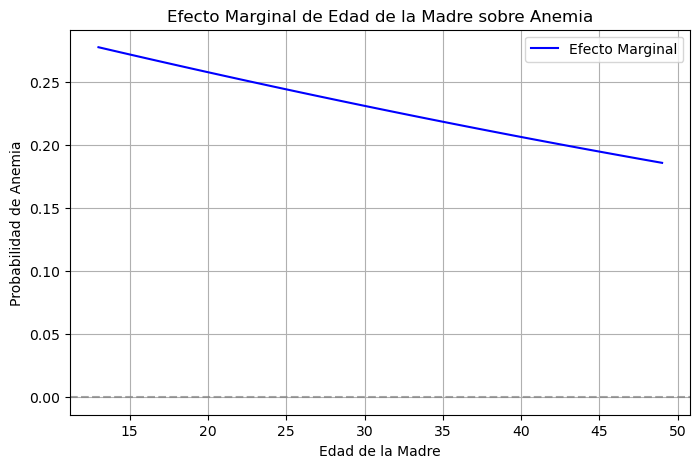

In [ ]:
# Definir el rango de valores para "edad_madre"
edad_madre_range = np.linspace(data['edad_madre'].min(), data['edad_madre'].max(), 50)

# Crear un dataframe con valores medios para todas las variables del modelo
X_mean = data[['edad_nino', 'sexo', 'edad_madre', 'primaria', 'secundaria', 'superior', 'rural','peso/edad SD']].mean()
X_plot = pd.DataFrame([X_mean] * len(edad_madre_range))

# Solo varía "edad_madre"
X_plot['edad_madre'] = edad_madre_range

# Agregar la constante para que coincida con el modelo
X_plot = sm.add_constant(X_plot)

# **Asegurar que las columnas coincidan con el modelo**
missing_cols = set(logit_model.params.index) - set(X_plot.columns)
for col in missing_cols:
    X_plot[col] = 0  # Agregamos las columnas faltantes con ceros

# Ordenar las columnas para que coincidan exactamente con el modelo
X_plot = X_plot[logit_model.params.index]

# Predecir las probabilidades
preds = logit_model.predict(X_plot)

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(edad_madre_range, preds, label="Efecto Marginal", color="b")
plt.xlabel("Edad de la Madre")
plt.ylabel("Probabilidad de Anemia")
plt.title("Efecto Marginal de Edad de la Madre sobre Anemia")
plt.axhline(y=0, color="gray", linestyle="--", alpha=0.7)
plt.legend()
plt.grid(True)
plt.show()

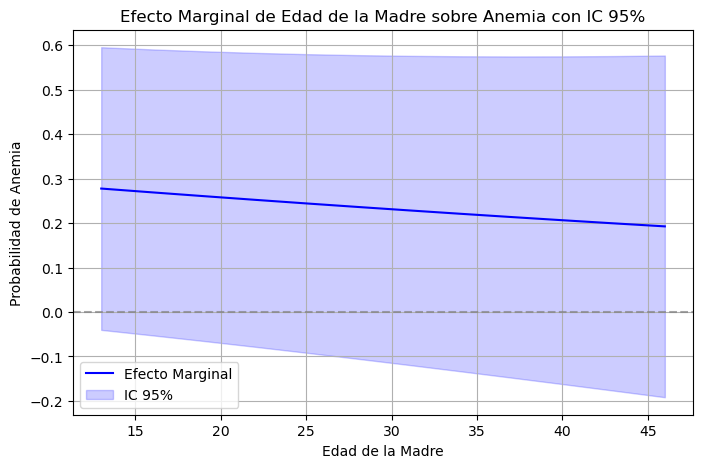

In [ ]:
# Definir el rango de valores para "edad_madre" (en intervalos de 3 años)
edad_madre_range = np.arange(data['edad_madre'].min(), data['edad_madre'].max(), 3)

# Crear un dataframe con valores medios para todas las variables del modelo
X_mean = data[['edad_nino', 'sexo', 'edad_madre', 'primaria', 'secundaria', 'superior', 'rural','peso/edad SD']].mean()
X_plot = pd.DataFrame([X_mean] * len(edad_madre_range))

# Solo varía "edad_madre"
X_plot['edad_madre'] = edad_madre_range

# Agregar la constante para que coincida con el modelo
X_plot = sm.add_constant(X_plot)

# **Asegurar que las columnas coincidan con el modelo**
missing_cols = set(logit_model.params.index) - set(X_plot.columns)
for col in missing_cols:
    X_plot[col] = 0  # Agregamos las columnas faltantes con ceros

# Ordenar las columnas para que coincidan exactamente con el modelo
X_plot = X_plot[logit_model.params.index]

# Predecir la probabilidad y los intervalos de confianza
preds = logit_model.predict(X_plot)

# Calcular los errores estándar de las predicciones
cov_matrix = logit_model.cov_params()
se_preds = np.sqrt(np.diag(X_plot @ cov_matrix @ X_plot.T))  # Fórmula para el error estándar de la predicción

# Intervalos de confianza (95%)
z_score = 1.96  # Valor de z para el 95% de confianza
lower_bound = preds - z_score * se_preds
upper_bound = preds + z_score * se_preds

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(edad_madre_range, preds, label="Efecto Marginal", color="b")
plt.fill_between(edad_madre_range, lower_bound, upper_bound, color="b", alpha=0.2, label="IC 95%")
plt.xlabel("Edad de la Madre")
plt.ylabel("Probabilidad de Anemia")
plt.title("Efecto Marginal de Edad de la Madre sobre Anemia con IC 95%")
plt.axhline(y=0, color="gray", linestyle="--", alpha=0.7)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#LOG ODDS

log_odds = logit_model.params
print("Log-Odds (Coeficientes en escala logit):")
print(log_odds)

Log-Odds (Coeficientes en escala logit):
const           0.245665
edad_nino      -0.018397
sexo           -0.149362
edad_madre     -0.014459
primaria        0.137994
secundaria     -0.044595
superior       -0.306666
rural           0.261604
peso/edad SD   -0.001187
dtype: float64


In [ ]:
#odds ratio
odds_ratios = np.exp(logit_model.params)
print("Odds Ratios:")
print(odds_ratios)

Odds Ratios:
const           1.278471
edad_nino       0.981771
sexo            0.861257
edad_madre      0.985645
primaria        1.147969
secundaria      0.956385
superior        0.735897
rural           1.299012
peso/edad SD    0.998813
dtype: float64


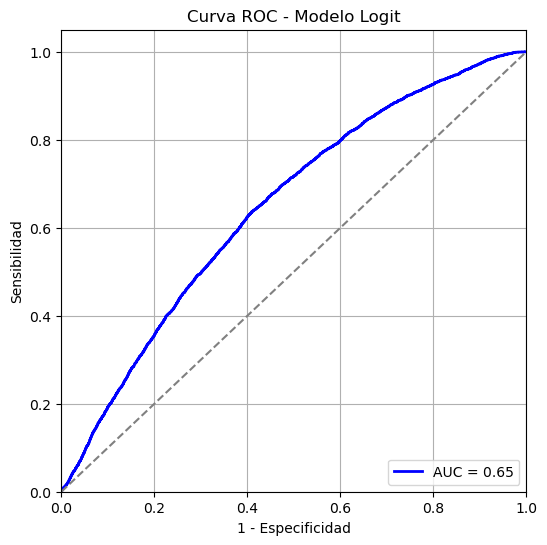

In [ ]:
# Obtener predicciones de probabilidad
y_pred_prob = logit_model.predict(X)

# Calcular valores para la curva ROC
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar la curva ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea diagonal (modelo aleatorio)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Especificidad')
plt.ylabel('Sensibilidad')
plt.title('Curva ROC - Modelo Logit')
plt.legend(loc='lower right')
plt.grid()
plt.show()

La curva ROC muestra que el modelo Logit tiene una capacidad de predicción baja (AUC = 0.65), lo que sugiere que no es muy efectivo en diferenciar entre niños con y sin anemia.

In [ ]:
# Poder predictivo

# Elegir un umbral de clasificación
threshold = 0.5
y_pred = (y_pred_prob >= threshold).astype(int)

# Calcular la matriz de confusión
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
# tn: true negatives
# fp: falsos positivos
# fn: false negatives
# tp: true positives

# Calcular sensibilidad y especificidad
sensibilidad = tp / (tp + fn)  # Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos)
especificidad = tn / (tn + fp)  # Verdaderos Negativos / (Verdaderos Negativos + Falsos Positivos)

print(f"Sensibilidad (TPR): {sensibilidad:.2f}")
print(f"Especificidad (TNR): {especificidad:.2f}")

Sensibilidad (TPR): 0.05
Especificidad (TNR): 0.97


Sensibilidad (TPR, True Positive Rate): Mide la capacidad del modelo para identificar correctamente los casos positivos (anemia).

* Muy baja capacidad del modelo para detectar anemia. Solo el 5% de los niños con anemia fueron correctamente identificados.

Especificidad (TNR, True Negative Rate): Mide la capacidad del modelo para identificar correctamente los casos negativos (sin anemia).

* Alta capacidad para identificar niños sin anemia. El modelo clasifica correctamente al 97% de los niños sin anemia.

### Modelo Probit

In [ ]:
# Definir las variables independientes
X = data[['edad_nino', 'sexo', 'edad_madre', 'primaria', 'secundaria', 'superior', 'rural', 'peso/edad SD']]
# Agregar la constante al modelo
X = sm.add_constant(X)
# Variable dependiente (anemia)
y = data['anemia']

# Modelo Logit
probit_model = sm.Probit(y, X).fit()
print(probit_model.summary())

Optimization terminated successfully.
         Current function value: 0.600201
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:                 anemia   No. Observations:                20408
Model:                         Probit   Df Residuals:                    20399
Method:                           MLE   Df Model:                            8
Date:                Sun, 22 Feb 2026   Pseudo R-squ.:                 0.04000
Time:                        12:52:55   Log-Likelihood:                -12249.
converged:                       True   LL-Null:                       -12759.
Covariance Type:            nonrobust   LLR p-value:                4.690e-215
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1869      0.107      1.743      0.081      -0.023       0.397
edad_nino       -0.0110

* Interpretación

Tener mas edad está asociado significativamente a una menor probabilidad de tener anemia.

Ser mujer está asociado significativamente a una menor probabilidad de tener anemia.

La edad de la madre está asociada significativamente a una menor probabilidad de que el niño tenga anemia.

Vivir en el área rural está asociado significativamente a una mayor probabilidad de tener anemia

Niños con mejor estado nutricional (desvío positivo del peso del niño respecto a la mediana de la referencia de su edad) tienen menor probabilidad de anemia.

In [ ]:
# Efectos marginales en la media de las variables
marginal_effects = probit_model.get_margeff(method="dydx", at="mean")
print(marginal_effects.summary())

       Probit Marginal Effects       
Dep. Variable:                 anemia
Method:                          dydx
At:                              mean
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
edad_nino       -0.0039      0.000    -19.943      0.000      -0.004      -0.003
sexo            -0.0328      0.007     -5.023      0.000      -0.046      -0.020
edad_madre      -0.0032      0.000     -6.566      0.000      -0.004      -0.002
primaria         0.0259      0.033      0.783      0.433      -0.039       0.091
secundaria      -0.0185      0.033     -0.564      0.573      -0.083       0.046
superior        -0.0764      0.034     -2.264      0.024      -0.143      -0.010
rural            0.0615      0.008      8.188      0.000       0.047       0.076
peso/edad SD -7.711e-05   7.81e-06     -9.880      0.000   -9.24e-05   -6.18e-05


* Interpretación: Cómo cambia la probabilidad de tener anemia cuando una variable cambia en una unidad, evaluado en un niño promedio (con valores medios en todas las demás variables)

Cada mes adicional de edad reduce la probabilidad de anemia en 0.39 puntos porcentuales. Esto sugiere que los niños más pequeños tienen mayor riesgo de anemia.

Ser mujer reduce la probabilidad de anemia en 3.28 puntos porcentuales en comparación con ser varón.

In [ ]:
# Efectos marginales promedio en toda la muestra
marginal_overall = probit_model.get_margeff(method="dydx", at="overall")
print(marginal_overall.summary())

       Probit Marginal Effects       
Dep. Variable:                 anemia
Method:                          dydx
At:                           overall
                  dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
edad_nino       -0.0038      0.000    -20.484      0.000      -0.004      -0.003
sexo            -0.0320      0.006     -5.031      0.000      -0.044      -0.020
edad_madre      -0.0032      0.000     -6.586      0.000      -0.004      -0.002
primaria         0.0253      0.032      0.783      0.433      -0.038       0.089
secundaria      -0.0180      0.032     -0.564      0.573      -0.081       0.045
superior        -0.0746      0.033     -2.265      0.023      -0.139      -0.010
rural            0.0601      0.007      8.231      0.000       0.046       0.074
peso/edad SD -7.533e-05   7.73e-06     -9.742      0.000   -9.05e-05   -6.02e-05


* Interpretación: Cómo cambia la probabilidad promedio de tener anemia en la muestra cuando una variable explicativa cambia en una unidad.

En promedio, cada mes adicional de edad reduce la probabilidad de anemia en ...

En promedio, ser mujer reduce la probabilidad de anemia en ...

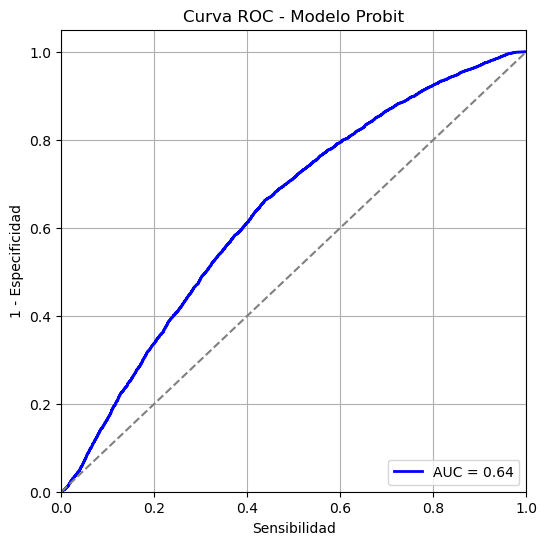

In [ ]:
# Obtener predicciones de probabilidad
y_pred_prob = probit_model.predict(X)

# Calcular valores para la curva ROC
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar la curva ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea diagonal (modelo aleatorio)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Sensibilidad')
plt.ylabel('1 - Especificidad')
plt.title('Curva ROC - Modelo Probit')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
# Poder predictivo

# Elegir un umbral de clasificación
threshold = 0.5
y_pred = (y_pred_prob >= threshold).astype(int)

# Calcular la matriz de confusión
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
# tn: true negatives
# fp: falsos positivos
# fn: false negatives
# tp: true positives

# Calcular sensibilidad y especificidad
sensibilidad = tp / (tp + fn)  # Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos)
especificidad = tn / (tn + fp)  # Verdaderos Negativos / (Verdaderos Negativos + Falsos Positivos)

print(f"Sensibilidad (TPR): {sensibilidad:.2f}")
print(f"Especificidad (TNR): {especificidad:.2f}")

Sensibilidad (TPR): 0.04
Especificidad (TNR): 0.97


* Muy baja capacidad del modelo para detectar anemia. Solo el 4% de los niños con anemia fueron correctamente identificados.


* Alta capacidad para identificar niños sin anemia. El modelo clasifica correctamente al 97% de los niños sin anemia.

In [ ]:
lpm_model = sm.OLS(y, X).fit()
lpm_preds = lpm_model.predict(X)  # Predicciones del LPM

# Modelo Logit
logit_model = sm.Logit(y, X).fit()
logit_preds = logit_model.predict(X)  # Predicciones del modelo Logit

# Modelo Probit
probit_model = sm.Probit(y, X).fit()
probit_preds = probit_model.predict(X)  # Predicciones del modelo Probit

predictions = pd.DataFrame({
    'LPM': lpm_preds,
    'Logit': logit_preds,
    'Probit': probit_preds
})

Optimization terminated successfully.
         Current function value: 0.598963
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.600201
         Iterations 7


In [ ]:
# Tabla descriptiva de las predicciones
descriptive_table = predictions.describe()

# Mostrar la tabla
print(descriptive_table)

                LPM         Logit        Probit
count  20408.000000  20408.000000  20408.000000
mean       0.317817      0.317817      0.317662
std        0.097753      0.101465      0.098397
min       -0.228686      0.000001      0.000430
25%        0.254881      0.247885      0.249703
50%        0.321789      0.316162      0.316195
75%        0.384830      0.388416      0.385218
max        0.587122      0.639544      0.615112


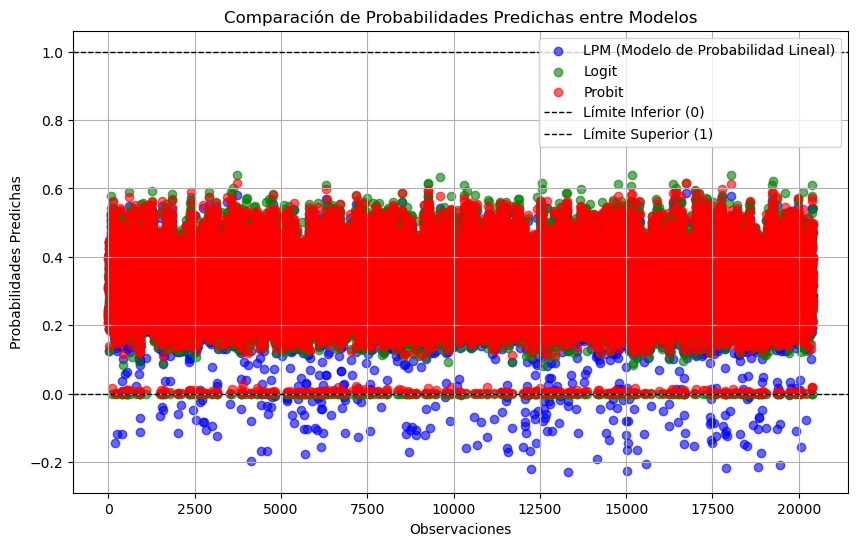

In [ ]:
# Gráfico de comparación
plt.figure(figsize=(10, 6))

# Predicciones del LPM
plt.scatter(range(len(lpm_preds)), lpm_preds, color='blue', alpha=0.6, label='LPM (Modelo de Probabilidad Lineal)')

# Predicciones del Logit
plt.scatter(range(len(logit_preds)), logit_preds, color='green', alpha=0.6, label='Logit')

# Predicciones del Probit
plt.scatter(range(len(probit_preds)), probit_preds, color='red', alpha=0.6, label='Probit')

# Límites de 0 y 1
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='Límite Inferior (0)')
plt.axhline(y=1, color='black', linestyle='--', linewidth=1, label='Límite Superior (1)')

# Configuración del gráfico
plt.title('Comparación de Probabilidades Predichas entre Modelos')
plt.xlabel('Observaciones')
plt.ylabel('Probabilidades Predichas')
plt.legend()
plt.grid()
plt.show()

## II. Introducción al análisis de series de tiempo

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Pueden descargar las bases de datos desde la web del BCRP (https://estadisticas.bcrp.gob.pe/estadisticas/series/), trabajaremos con los archivos csv. Los módulos de interés para la sesión se encuentran en PAIDEIA.

#### Ejercicios Prácticos - BCRP (Exportaciones de Productos Mineros - Serie Mensual)

In [ ]:
# RUTA = r"C:\Users\Windows 10\Dropbox\QLAB\Cursos\Verano 2025\Escuela de verano Q-LAB\Fundamentos de Econometria Aplicada\Fundamentos de Econometria Aplicada\Modulo 5"

data = pd.read_csv(os.path.join(RUTA, "Mensuales-20250131-172959.csv"), header=1)

# RUTA = r"C:\Users\Windows 10\Dropbox\QLAB\Cursos\Verano 2025\Escuela de verano Q-LAB\Fundamentos de Econometria Aplicada\Fundamentos de Econometria Aplicada\Modulo 5"
#data = pd.read_csv(os.path.join(RUTA, "Mensuales-20250131-172959.csv"))

#data = pd.read_csv("Mensuales-20250131-172959.csv", header=1) # indicar que la primera columna es el nombre de las variables
data

,Unnamed: 0,Exportaciones por grupo de productos - valores FOB (millones US$) - Productos Tradicionales - Mineros
0,Ene12,2369.059819
1,Feb12,2367.324313
2,Mar12,2473.288787
3,Abr12,1791.083346
4,May12,2260.723054
...,...,...
150,Jul24,4123.376771
151,Ago24,4211.469992
152,Sep24,4076.231891
153,Oct24,3886.969304


In [ ]:
# Renombrar variable
data.rename(columns={'Unnamed: 0': 'Date', 'Exportaciones por grupo de productos - valores FOB (millones US$) - Productos Tradicionales - Mineros': 'Exportaciones Mineras'}, inplace=True)
data

,Date,Exportaciones Mineras
0,Ene12,2369.059819
1,Feb12,2367.324313
2,Mar12,2473.288787
3,Abr12,1791.083346
4,May12,2260.723054
...,...,...
150,Jul24,4123.376771
151,Ago24,4211.469992
152,Sep24,4076.231891
153,Oct24,3886.969304


In [ ]:
# Es importante que el programa reconozca la variable Date como una variable de temporal

# Crear el diccionario de meses con sus valores numéricos
meses = {
    'Ene': '01', 'Feb': '02', 'Mar': '03', 'Abr': '04',
    'May': '05', 'Jun': '06', 'Jul': '07', 'Ago': '08',
    'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dic': '12'
}

# Extraer el mes y el año de la variable Date
data['Mes'] = data['Date'].str[:3]  # Extrae los primeros 3 caracteres (el mes)
data['Año'] = '20' + data['Date'].str[-2:]  # Agrega "20" delante del año

# Reemplazar el nombre del mes por su valor numérico
data['Mes'] = data['Mes'].map(meses)

# Crear la fecha en formato YYYY-MM
data['Fecha'] = data['Año'] + '-' + data['Mes']

# Convertir a tipo Period (mensual) para que pandas lo trate como fecha
data['Fecha'] = pd.to_datetime(data['Fecha']).dt.to_period('M')

data


,Date,Exportaciones Mineras,Mes,Año,Fecha
0,Ene12,2369.059819,01,2012,2012-01
1,Feb12,2367.324313,02,2012,2012-02
2,Mar12,2473.288787,03,2012,2012-03
3,Abr12,1791.083346,04,2012,2012-04
4,May12,2260.723054,05,2012,2012-05
...,...,...,...,...,...
150,Jul24,4123.376771,07,2024,2024-07
151,Ago24,4211.469992,08,2024,2024-08
152,Sep24,4076.231891,09,2024,2024-09
153,Oct24,3886.969304,10,2024,2024-10


In [ ]:
# Verificar el tipo de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype    
---  ------                 --------------  -----    
 0   Date                   155 non-null    object   
 1   Exportaciones Mineras  155 non-null    float64  
 2   Mes                    155 non-null    object   
 3   Año                    155 non-null    object   
 4   Fecha                  155 non-null    period[M]
dtypes: float64(1), object(3), period[M](1)
memory usage: 6.2+ KB


In [ ]:
# A partir de la base data creamos una base data1 en la que el índice es la variable temporal
exportaciones=data[['Fecha', 'Exportaciones Mineras']]
exportaciones.set_index('Fecha', inplace=True)
exportaciones.index = exportaciones.index.to_timestamp()
exportaciones

,Exportaciones Mineras
Fecha,
2012-01-01,2369.059819
2012-02-01,2367.324313
2012-03-01,2473.288787
2012-04-01,1791.083346
2012-05-01,2260.723054
...,...
2024-07-01,4123.376771
2024-08-01,4211.469992
2024-09-01,4076.231891


Text(0.5, 0, 'Años')

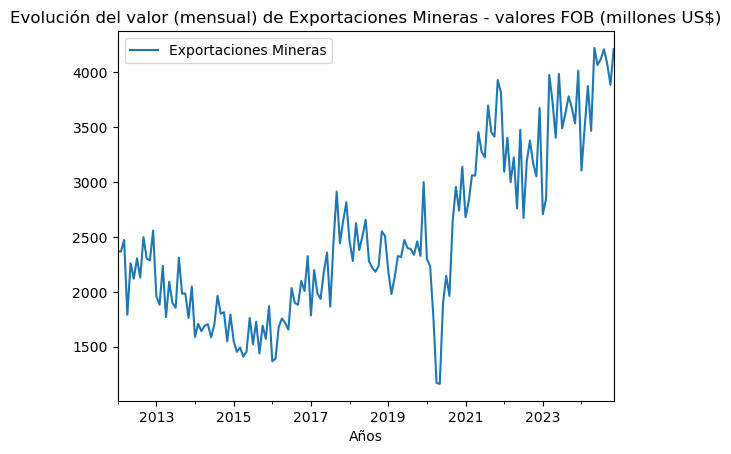

In [ ]:
# Graficamos
exportaciones.plot()
plt.title('Evolución del valor (mensual) de Exportaciones Mineras - valores FOB (millones US$)')
plt.xlabel("Años")

2020: Caída abrupta en las exportaciones durante el periodo de la pandemia por COVID-19. Asociado a:

    Cierre temporal de operaciones mineras.
    Disrupción en la cadena de suministros global.
    Caída en la demanda mundial de minerales.
    
Se observan fluctuaciones significativas en los valores de exportación, esto puede estar asociado a sensibilidad ante:

    Condiciones económicas globales.
    Precios de los minerales en los mercados internacionales.

### Tendencia y Estacionalidad

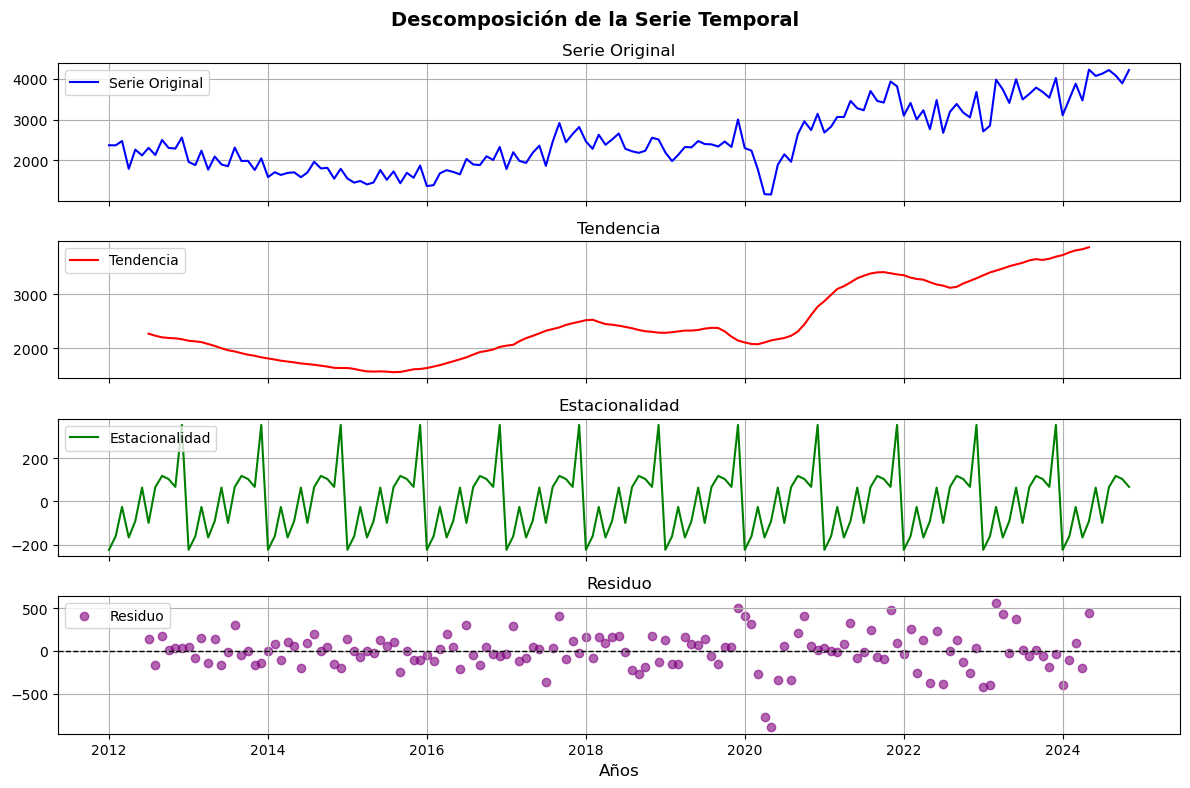

In [ ]:
# Aplicar la descomposición estacional (seasonal_decompose)
descomposicion = sm.tsa.seasonal_decompose(exportaciones['Exportaciones Mineras'], model='additive', period=12)

# Crear el gráfico
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

# Gráfico de la serie original
axes[0].plot(exportaciones.index, exportaciones['Exportaciones Mineras'], label="Serie Original", color="blue")
axes[0].set_title("Serie Original", fontsize=12)
axes[0].legend(loc="upper left")
axes[0].grid(True)

# Gráfico de la tendencia
axes[1].plot(exportaciones.index, descomposicion.trend, label="Tendencia", color="red")
axes[1].set_title("Tendencia", fontsize=12)
axes[1].legend(loc="upper left")
axes[1].grid(True)

# Gráfico de la estacionalidad
axes[2].plot(exportaciones.index, descomposicion.seasonal, label="Estacionalidad", color="green")
axes[2].set_title("Estacionalidad", fontsize=12)
axes[2].legend(loc="upper left")
axes[2].grid(True)

# Gráfico del residuo
axes[3].scatter(exportaciones.index, descomposicion.resid, label="Residuo", color="purple", alpha=0.6)
axes[3].axhline(y=0, color='black', linestyle='--', linewidth=1)  # Línea base en 0
axes[3].set_title("Residuo", fontsize=12)
axes[3].legend(loc="upper left")
axes[3].grid(True)


plt.xlabel("Años", fontsize=12)
fig.suptitle("Descomposición de la Serie Temporal", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- Tendencia

La tendencia refleja ciclos en el sector minero, con periodos de expansión y contracción.

- Estacionalidad

Se observan patrones repetitivos en ciclos anuales. Cada año hay picos y caídas similares, indicando que las exportaciones mineras siguen un comportamiento estacional. Esto puede estar asociados a:
Fluctuaciones en la demanda internacional de minerales.
Ciclos de producción minera (ej: periodos de extracción).

###  Estacionarizando la serie

C:\Users\raruf\AppData\Local\Temp\ipykernel_10160\3528313601.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exportaciones.loc[:, 'Exportaciones_Diff1'] = exportaciones['Exportaciones Mineras'].diff().dropna()


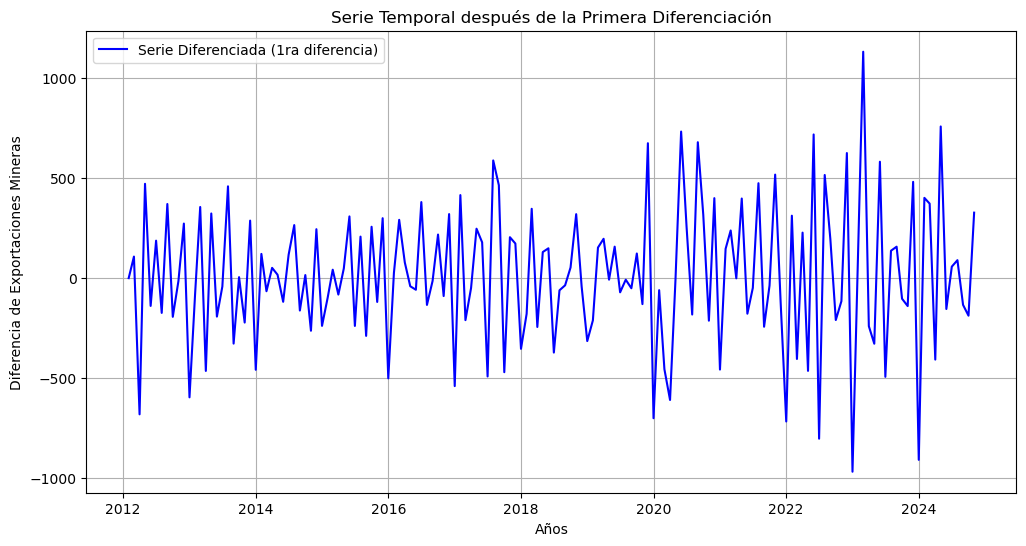

In [ ]:
# Aplicar primera diferenciación para eliminar tendencia
exportaciones.loc[:, 'Exportaciones_Diff1'] = exportaciones['Exportaciones Mineras'].diff().dropna()

# Graficar la serie diferenciada
plt.figure(figsize=(12, 6))
plt.plot(exportaciones['Exportaciones_Diff1'], label='Serie Diferenciada (1ra diferencia)', color='blue')
plt.title("Serie Temporal después de la Primera Diferenciación")
plt.xlabel("Años")
plt.ylabel("Diferencia de Exportaciones Mineras")
plt.legend()
plt.grid()
plt.show()

* Primeras diferencias

Se calcula la diferencia entre cada observación y la anterior. Esto elimina la tendencia, dejando solo variaciones en la serie.

En el gráfico se observa mayor estabilidad en torno a un valor medio, lo que sugiere que la serie puede estar más cerca de ser estacionaria.